In [27]:
from pathlib import Path
import cv2
import numpy as np
from fundus_data_toolkit.functional import autofit_fundus_resolution, reverse_autofit
from multistyleseg.experiments.fundus.ensemble import get_ensemble_model
from tqdm.auto import tqdm
import torch
import torchmetrics as tm
from torchmetrics import PrecisionRecallCurve
import matplotlib.pyplot as plt
import numpy as np
from multistyleseg.analysis.utils import LesionsUtils

In [28]:
ROOT_LESIONS = Path(
    "/home/clement/Documents/data/IDRID/A. Segmentation/2. All Segmentation Groundtruths/b. Testing Set"
)


class IDRIDLesion:
    MICROANEURYSMS = "1. Microaneurysms"
    HEMORRHAGES = "2. Haemorrhages"
    HARD_EXUDATES = "3. Hard Exudates"
    SOFT_EXUDATES = "4. Soft Exudates"

    @staticmethod
    def get_lesion_path(lesion: str, img_name: str) -> Path:
        path = (ROOT_LESIONS / lesion).glob(f"{img_name}*.tif")
        return next(path, None)

    @staticmethod
    def get_lesions_mask(img_name: str, h=None, w=None) -> Path:
        lesions = []
        for lesion in [
            IDRIDLesion.SOFT_EXUDATES,
            IDRIDLesion.HARD_EXUDATES,
            IDRIDLesion.HEMORRHAGES,
            IDRIDLesion.MICROANEURYSMS,
        ]:
            path = IDRIDLesion.get_lesion_path(lesion, img_name)
            if path:
                lesions.append(cv2.imread(str(path), cv2.IMREAD_GRAYSCALE))
            else:
                lesions.append(np.zeros((h, w), dtype=np.uint8))
        return lesions


ROOT_IMG = Path(
    "/home/clement/Documents/data/IDRID/A. Segmentation/1. Original Images/b. Testing Set"
)
IMG_PATHS = sorted(list(ROOT_IMG.glob("*.jpg")))
ensemble_model = (
    get_ensemble_model(
        1024,
        model_choices=[
            # "SERESNET_UNET",
            # "UNET",
            # "SEGFORMER",
            "CONVNEXT_UNET"
        ],
    )
    .cuda()
    .eval()
)

MEAN = torch.tensor([0.485, 0.456, 0.406], device="cuda")
STD = torch.tensor([0.229, 0.224, 0.225], device="cuda")


In [29]:
def preprocess_image(img_path: Path):
    img = cv2.imread(str(img_path))
    orginal_shape = img.shape[:2]
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img, params = autofit_fundus_resolution(img, max_size=1536)
    return img, params, orginal_shape


def inference_image(img_path: Path):
    img, params, original_shape = preprocess_image(img_path)
    img_tensor = (
        torch.from_numpy(img).float().permute(2, 0, 1).unsqueeze(0).cuda() / 255.0
    )
    img_tensor = (img_tensor - MEAN[None, :, None, None]) / STD[None, :, None, None]
    with torch.no_grad():
        pred = ensemble_model(img_tensor)
    pred = (
        pred.softmax(dim=1).cpu().squeeze(0).permute(1, 2, 0).numpy().astype(np.float32)
    )
    pred = reverse_autofit(pred, **params)
    # Make sure the prediction has the same shape as the original image
    pred = cv2.resize(
        pred, (original_shape[1], original_shape[0]), interpolation=cv2.INTER_LINEAR
    )

    return pred


preds = []
gts = []
for img_path in tqdm(IMG_PATHS):
    preds.append(inference_image(img_path))
    gts.append(
        IDRIDLesion.get_lesions_mask(
            img_path.stem, h=preds[-1].shape[0], w=preds[-1].shape[1]
        )
    )

  0%|          | 0/27 [00:00<?, ?it/s]

In [30]:
results = {}
for lesion_idx, lesion in enumerate(["CWS", "EX", "HE", "MA"]):
    metric = PrecisionRecallCurve(task="binary", thresholds=33).cuda()
    for pred, gt in tqdm(zip(preds, gts)):
        proba = torch.from_numpy(pred[..., lesion_idx + 1]).cuda()
        # Slightly dilate the prediction for Microaneurysms to account for their small size
        gt_lesion = (torch.from_numpy(gt[lesion_idx]) > 0).cuda()
        metric.update(proba, gt_lesion)
    precision, recall, thresholds = metric.compute()
    results[lesion] = {
        "precision": precision.cpu().numpy(),
        "recall": recall.cpu().numpy(),
        "thresholds": thresholds.cpu().numpy(),
    }

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

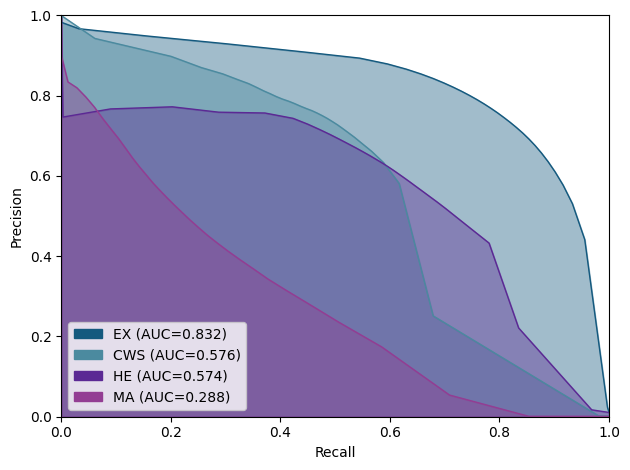

In [31]:
# Reorder the dict to have the order: EX, CWS, HE, MA
lesion_order = ["EX", "CWS", "HE", "MA"]
results = {lesion: results[lesion] for lesion in lesion_order}
for lesion in results:
    precision = np.array(results[lesion]["precision"])
    recall = np.array(results[lesion]["recall"])
    precision = np.nan_to_num(precision, nan=1.0)
    # Remove NaNs from both based on precision
    mask = ~np.isnan(precision)
    precision, recall = precision[mask], recall[mask]

    # Sort by recall
    sorted_indices = np.argsort(recall)
    precision = precision[sorted_indices]
    recall = recall[sorted_indices]
    auc = np.trapz(precision, recall)

    # Fill the area under the curve
    plt.fill_between(
        recall,
        precision,
        alpha=0.4,
        color=LesionsUtils.get_color(lesion),
        label=f"{lesion} (AUC={auc:.3f})",
    )
    plt.plot(recall, precision, color=LesionsUtils.get_color(lesion), linewidth=1)

    plt.xlabel("Recall")
    plt.ylabel("Precision")

# Change the opacity of the legend
legend = plt.legend()
for handle in legend.legend_handles:
    handle.set_alpha(1.0)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()

plt.show()

In [32]:
# Format the results in a table
import pandas as pd

table = []
for lesion in results:
    precision = np.array(results[lesion]["precision"])
    recall = np.array(results[lesion]["recall"])
    precision = np.nan_to_num(precision, nan=1.0)
    # Remove NaNs from both based on precision
    mask = ~np.isnan(precision)
    precision, recall = precision[mask], recall[mask]

    # Sort by recall
    sorted_indices = np.argsort(recall)
    precision = precision[sorted_indices]
    recall = recall[sorted_indices]
    auc = np.trapz(precision, recall)
    table.append({"Lesion": lesion, "Ensemble": auc})
df = pd.DataFrame(table).set_index("Lesion")
df = df.reindex(["EX", "CWS", "HE", "MA"])

others_results = {
    "Team": ["VRT", "PATech", "iFLYTEK-MIG"],
    "EX": [0.7127, 0.885, 0.8741],
    "CWS": [0.6995, None, 0.6588],
    "HE": [0.6804, 0.649, 0.5588],
    "MA": [0.4951, 0.474, 0.5017],
}

# Add the other results to the dataframe
others_df = pd.DataFrame(others_results).set_index("Team").T
others_df = others_df.reindex(df.index)
df = pd.concat([df, others_df], axis=1).T
# Add an average column
df["Average"] = df.mean(axis=1)

print(df.to_latex(index=True, float_format="%.3f"))

\begin{tabular}{lrrrrr}
\toprule
Lesion & EX & CWS & HE & MA & Average \\
\midrule
Ensemble & 0.832 & 0.576 & 0.574 & 0.288 & 0.567 \\
VRT & 0.713 & 0.700 & 0.680 & 0.495 & 0.647 \\
PATech & 0.885 & NaN & 0.649 & 0.474 & 0.669 \\
iFLYTEK-MIG & 0.874 & 0.659 & 0.559 & 0.502 & 0.648 \\
\bottomrule
\end{tabular}

